# Experiment 4 — Comparative Study of Deep CNN Architectures Using Transfer Learning

**CS3807 – Deep Learning Laboratory** · Shiv Nadar University Chennai
**Name:** R S Kirithic &nbsp;·&nbsp; **Register No.:** 24011101082 &nbsp;·&nbsp; **Section:** AIDS 'B'

**Dataset:** CIFAR-10, loaded from Google Drive (`My Drive/DL/cifar-10-batches-py`) — the standard Python-pickled version described on the [CIFAR page](https://www.cs.toronto.edu/~kriz/cifar.html). No download step is used; the files are read directly from Drive.

**Notes on scope**
- **Main pipeline (Tasks 1–5, fine-tuning, evaluation):** runs on the **full** CIFAR-10 dataset (50,000 train / 10,000 test), using **MobileNetV2** as the primary transfer-learning model. *(Assumption: since the Additional Exercises separately ask to "implement transfer learning using VGG16" and "repeat the experiment using ResNet50", those two are clearly meant to be extra runs on top of a main model — so the main Task 2–5 pipeline uses MobileNetV2, the remaining non-optional choice from the manual's list. Say the word if you'd rather the main run used VGG16 or ResNet50 instead.)*
- **Section 16 (Hyperparameter Study) and Section 20 (Additional Exercises, all six):** run on a **smaller stratified subset**, as requested, so they don't take too long. All six Additional Exercises are covered: #1 VGG16 and #2 ResNet50 get their own transfer-learning runs; #3 (Adam vs SGD) and #5 (Precision/Recall/F1) are pulled straight from the Section 16 search results and the Task 5 evaluation since those already produce that exact comparison; #4 (frozen vs fine-tuned) reuses the Task 4 before/after numbers; and #6 is now a full three-way LeNet-5 vs AlexNet-style vs ResNet50 comparison, LeNet-5 included.
- Every plot is saved as a separate **.eps file at 600 DPI**, Times New Roman, font size 13, matching the house style from the CNN/CIFAR-10 lab.
- All figures are written straight to Drive (`My Drive/DL/Experiment4_Figures/`) so nothing is lost if the runtime disconnects, and there's a zip-and-download cell at the very end too.

Run the cells top to bottom. Once it's done, send me the printed outputs (and the figures if you want them embedded) and I'll build the LaTeX report from the real numbers.

## 0. Setup

In [1]:
# Install Times New Roman (Microsoft core fonts) for the matplotlib figures.
# Only needs to run once per fresh Colab runtime.
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | sudo debconf-set-selections
!apt-get install -y -qq ttf-mscorefonts-installer > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib
print("Font install step done.")

Font install step done.


In [2]:
import os, glob, time, pickle, zipfile, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

from google.colab import drive
drive.mount('/content/drive')

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Paths ----
# Adjust DATASET_DIR if your "cifar-10-batches-py" folder lives somewhere else in Drive.
DATASET_DIR = "/content/drive/MyDrive/DL/cifar-10-batches-py"
FIG_DIR = "/content/drive/MyDrive/DL/Experiment4_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

assert os.path.isdir(DATASET_DIR), (
    f"Could not find {DATASET_DIR}. Update DATASET_DIR to point at your "
    f"cifar-10-batches-py folder in Drive (see My Drive > DL > cifar-10-batches-py)."
)
print("Dataset folder found:", DATASET_DIR)
print("Contents:", sorted(os.listdir(DATASET_DIR)))

# ---- Plot style: Times New Roman, size 13, saved as 600 DPI EPS ----
for fp in glob.glob('/usr/share/fonts/truetype/msttcorefonts/*Times*'):
    try:
        fm.fontManager.addfont(fp)
    except Exception as e:
        print("Could not register font:", fp, e)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 13

def save_fig(fig, name):
    """Save a matplotlib figure as a 600 DPI EPS file in FIG_DIR."""
    path = os.path.join(FIG_DIR, f"{name}.eps")
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print("Saved:", path)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
Dataset folder found: /content/drive/MyDrive/DL/cifar-10-batches-py
Contents: ['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'readme.html', 'test_batch']
TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1: Dataset Preparation

Loading CIFAR-10 directly from the pickled batch files in Drive (not via `keras.datasets` and not by downloading). Each `data_batch_i` / `test_batch` file unpickles to a dict with keys `b'batch_label'`, `b'labels'`, `b'data'`, `b'filenames'` — `data` is a `(10000, 3072)` uint8 array where each row packs 1024 red + 1024 green + 1024 blue values for one 32x32 image. `batches.meta` holds the class names. This matches the format documented on the CIFAR page.

In [3]:
def unpickle(file_path):
    with open(file_path, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

def batch_to_arrays(d):
    raw = d[b'data']                                    # (N, 3072) uint8
    labels = np.array(d[b'labels'], dtype=np.int64)      # (N,)
    images = raw.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # (N,32,32,3)
    return images, labels

# ---- Load the 5 training batches ----
train_images, train_labels = [], []
for i in range(1, 6):
    d = unpickle(os.path.join(DATASET_DIR, f"data_batch_{i}"))
    imgs, labs = batch_to_arrays(d)
    train_images.append(imgs)
    train_labels.append(labs)
X_train_raw = np.concatenate(train_images, axis=0)
y_train_int = np.concatenate(train_labels, axis=0)

# ---- Load the test batch ----
d_test = unpickle(os.path.join(DATASET_DIR, "test_batch"))
X_test_raw, y_test_int = batch_to_arrays(d_test)

# ---- Class names from batches.meta ----
meta = unpickle(os.path.join(DATASET_DIR, "batches.meta"))
label_names = [x.decode('utf-8') for x in meta[b'label_names']]
NUM_CLASSES = len(label_names)
print("Classes:", label_names)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
# ---- Task 1, step 2: normalize pixel values to [0, 1] ----
X_train = X_train_raw.astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0

y_train_onehot = tf.keras.utils.to_categorical(y_train_int, NUM_CLASSES)
y_test_onehot = tf.keras.utils.to_categorical(y_test_int, NUM_CLASSES)

print(f"Pixel value range: [{X_train.min():.2f}, {X_train.max():.2f}]")

# ---- Task 1, step 4: print dataset dimensions ----
print("Training images shape:", X_train.shape, X_train.dtype)
print("Training labels shape:", y_train_onehot.shape)
print("Testing images shape :", X_test.shape, X_test.dtype)
print("Testing labels shape :", y_test_onehot.shape)
print("Number of classes    :", NUM_CLASSES)
print("Image size           : 32 x 32 x 3")

Pixel value range: [0.00, 1.00]
Training images shape: (50000, 32, 32, 3) float32
Training labels shape: (50000, 10)
Testing images shape : (10000, 32, 32, 3) float32
Testing labels shape : (10000, 10)
Number of classes    : 10
Image size           : 32 x 32 x 3


Saved: /content/drive/MyDrive/DL/Experiment4_Figures/01_sample_images.eps


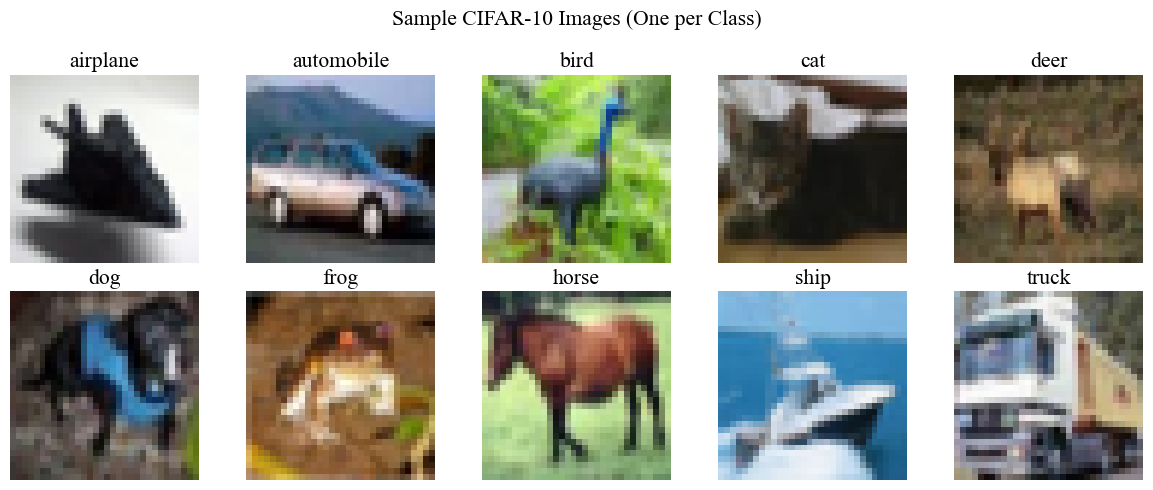

In [5]:
# ---- Task 1, step 3: display ten sample images (one per class) and save ----
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_id, ax in enumerate(axes.flat):
    idx = np.where(y_train_int == class_id)[0][0]
    ax.imshow(X_train[idx])
    ax.set_title(label_names[class_id])
    ax.axis('off')
fig.suptitle("Sample CIFAR-10 Images (One per Class)")
plt.tight_layout()
save_fig(fig, "01_sample_images")
plt.show()

## Task 2: Transfer Learning Model Setup (MobileNetV2)

Main model: **MobileNetV2**, pretrained on ImageNet, convolutional base frozen, with a
`GlobalAveragePooling2D -> Dense(ReLU) -> Dense(10, Softmax)` head on top, as specified in the manual.

CIFAR-10 images are natively 32x32, which is too small for a pretrained ImageNet backbone to extract
useful features from (it would collapse to a roughly 1x1 feature map). They are resized to **96x96**
on the fly inside the `tf.data` pipeline (a supported MobileNetV2 input size, and a common practical
choice for CIFAR-10 transfer learning) rather than pre-resizing the whole array, which would use several
GB of RAM. Since Task 1 already normalized pixels to [0, 1], the per-backbone `preprocess_input`
functions are skipped here to avoid re-scaling the data twice.

In [6]:
IMG_SIZE = 96
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def build_transfer_model(base_ctor, input_shape=(IMG_SIZE, IMG_SIZE, 3),
                          dense_units=128, num_classes=NUM_CLASSES,
                          weights='imagenet', frozen='all', unfreeze_last_n=30,
                          model_name="transfer_model"):
    """Build a transfer-learning model: pretrained base + GAP + Dense(ReLU) + Dense(Softmax).
    frozen='all'    -> whole base is frozen (Task 2/3 default)
    frozen='partial'-> base is trainable except the first (len-unfreeze_last_n) layers,
                        i.e. only the last conv block is unfrozen (Task 4 fine-tuning)
    """
    base = base_ctor(include_top=False, weights=weights, input_shape=input_shape)
    if frozen == 'all':
        base.trainable = False
    elif frozen == 'partial':
        base.trainable = True
        for layer in base.layers[:-unfreeze_last_n]:
            layer.trainable = False
    else:
        raise ValueError("frozen must be 'all' or 'partial'")

    inputs = layers.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs, name=model_name)
    return model, base

def make_dataset(X, y_onehot, img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False, seed=SEED):
    """tf.data pipeline that resizes [0,1]-normalized images on the fly (memory-safe)."""
    ds = tf.data.Dataset.from_tensor_slices((X, y_onehot))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=seed)
    def _resize(img, label):
        img = tf.image.resize(img, [img_size, img_size], method='bilinear')
        return img, label
    ds = ds.map(_resize, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)
    return ds

mobilenet_model, mobilenet_base = build_transfer_model(
    tf.keras.applications.MobileNetV2, dense_units=128, frozen='all',
    model_name="MobileNetV2_transfer")
mobilenet_model.summary()
print("Total parameters:", mobilenet_model.count_params())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Total parameters: 2423242


## Task 3: Model Training (Base Model, Frozen Backbone)

Optimizer Adam (lr = 0.001), batch size 32, categorical cross-entropy, accuracy metric,
10% validation split, trained on the **full** training set — as specified in the manual.

In [7]:
# 90/10 stratified train/validation split of the full training set
X_tr, X_val, y_tr_int, y_val_int = train_test_split(
    X_train, y_train_int, test_size=0.1, random_state=SEED, stratify=y_train_int)
y_tr_onehot = tf.keras.utils.to_categorical(y_tr_int, NUM_CLASSES)
y_val_onehot = tf.keras.utils.to_categorical(y_val_int, NUM_CLASSES)

train_ds = make_dataset(X_tr, y_tr_onehot, shuffle=True)
val_ds = make_dataset(X_val, y_val_onehot, shuffle=False)
test_ds = make_dataset(X_test, y_test_onehot, shuffle=False)

print("Train / Val / Test sizes:", len(X_tr), len(X_val), len(X_test))

MAIN_EPOCHS = 12

mobilenet_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                         loss='categorical_crossentropy', metrics=['accuracy'])

start = time.time()
history_base = mobilenet_model.fit(train_ds, validation_data=val_ds,
                                    epochs=MAIN_EPOCHS, shuffle=False, verbose=1)
base_train_time = time.time() - start
print(f"\nBase-model training time: {base_train_time:.2f} seconds ({MAIN_EPOCHS} epochs)")

pre_ft_loss, pre_ft_acc = mobilenet_model.evaluate(test_ds, verbose=0)
print(f"Test accuracy BEFORE fine-tuning: {pre_ft_acc:.4f}")

Train / Val / Test sizes: 45000 5000 10000
Epoch 1/12
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.7512 - loss: 0.7151 - val_accuracy: 0.7902 - val_loss: 0.6006
Epoch 2/12
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8036 - loss: 0.5553 - val_accuracy: 0.7994 - val_loss: 0.5701
Epoch 3/12
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8229 - loss: 0.4977 - val_accuracy: 0.8088 - val_loss: 0.5417
Epoch 4/12
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8376 - loss: 0.4556 - val_accuracy: 0.8106 - val_loss: 0.5488
Epoch 5/12
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8543 - loss: 0.4094 - val_accuracy: 0.7990 - val_loss: 0.5864
Epoch 6/12
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8682 - loss: 0.3703 - val_accuracy: 0.8150 - val_loss: 0.5545
Epoch 7/12
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8781 - loss: 0.3384 - val_accuracy: 0.8186 - val_loss: 0.5554
Epoch 8/12
1407/1407 ━━━━━━━━━━━━

## Task 4: Fine-Tuning

Unfreeze the last convolutional block of the MobileNetV2 base (last 30 of its layers), recompile
with a lower learning rate (1e-5, standard practice so fine-tuning doesn't wreck the pretrained
weights), and continue training for a few more epochs, again on the full training set.

In [8]:
FT_EPOCHS = 6
FT_UNFREEZE_LAST_N = 30
FT_LR = 1e-5

mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-FT_UNFREEZE_LAST_N]:
    layer.trainable = False
n_trainable_layers = sum(1 for l in mobilenet_base.layers if l.trainable)
print(f"Unfroze the last {FT_UNFREEZE_LAST_N} of {len(mobilenet_base.layers)} base layers "
      f"({n_trainable_layers} trainable).")

mobilenet_model.compile(optimizer=optimizers.Adam(learning_rate=FT_LR),
                         loss='categorical_crossentropy', metrics=['accuracy'])

start = time.time()
history_ft = mobilenet_model.fit(train_ds, validation_data=val_ds,
                                  epochs=FT_EPOCHS, shuffle=False, verbose=1)
ft_train_time = time.time() - start
print(f"\nFine-tuning time: {ft_train_time:.2f} seconds ({FT_EPOCHS} epochs)")

post_ft_loss, post_ft_acc = mobilenet_model.evaluate(test_ds, verbose=0)
print(f"\nTest accuracy BEFORE fine-tuning: {pre_ft_acc:.4f}")
print(f"Test accuracy AFTER  fine-tuning: {post_ft_acc:.4f}")
print(f"Total training time (base + fine-tune): {base_train_time + ft_train_time:.2f} seconds")

Unfroze the last 30 of 154 base layers (30 trainable).
Epoch 1/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 26ms/step - accuracy: 0.6969 - loss: 1.9542 - val_accuracy: 0.7896 - val_loss: 1.0751
Epoch 2/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.7747 - loss: 1.0810 - val_accuracy: 0.7904 - val_loss: 1.0116
Epoch 3/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8062 - loss: 0.7848 - val_accuracy: 0.7938 - val_loss: 0.9614
Epoch 4/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8284 - loss: 0.6113 - val_accuracy: 0.8074 - val_loss: 0.8615
Epoch 5/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8479 - loss: 0.5029 - val_accuracy: 0.8104 - val_loss: 0.7993
Epoch 6/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.8669 - loss: 0.4092 - val_accuracy: 0.8158 - val_loss: 0.7602

Fine-tuning time: 158.69 seconds (6 epochs)

Test accuracy BEFORE fine-tuning: 0.8054
Test accuracy AFTER  fine-tuning: 0.8026
Total training time (base + fin

## Task 5 & Mandatory Plots: Training Curves, Evaluation, Confusion Matrix

Saved: /content/drive/MyDrive/DL/Experiment4_Figures/02_training_accuracy.eps


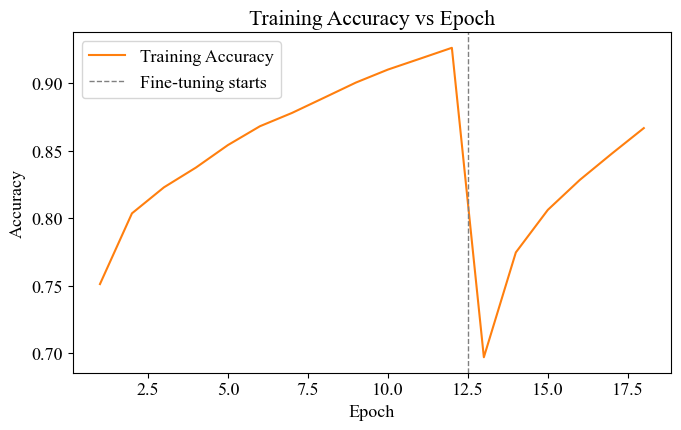

Saved: /content/drive/MyDrive/DL/Experiment4_Figures/03_validation_accuracy.eps


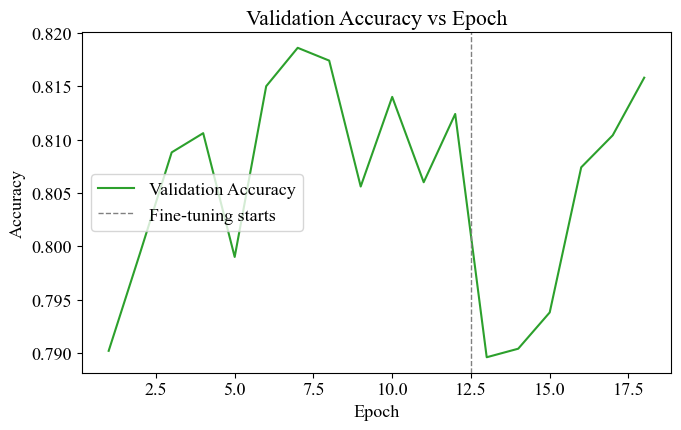

Saved: /content/drive/MyDrive/DL/Experiment4_Figures/04_training_loss.eps


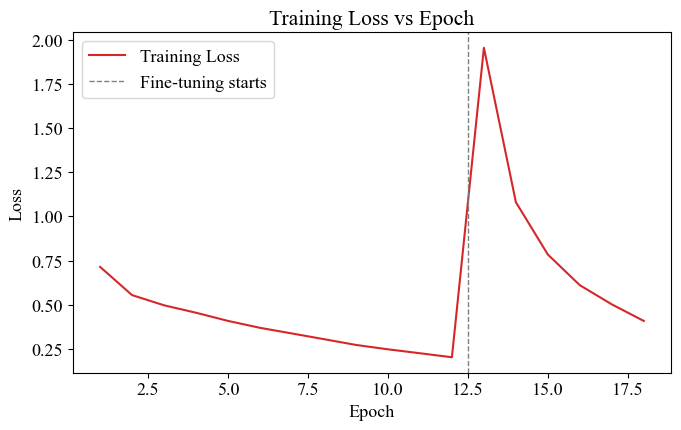

Saved: /content/drive/MyDrive/DL/Experiment4_Figures/05_validation_loss.eps


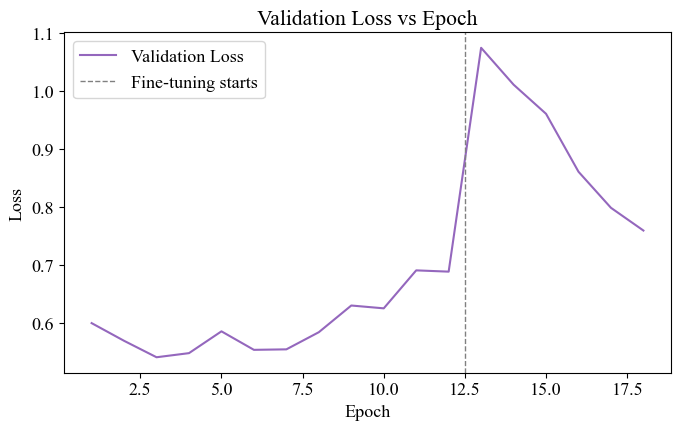

In [9]:
# ---- Combine the base-training and fine-tuning histories into continuous curves ----
train_acc = history_base.history['accuracy'] + history_ft.history['accuracy']
val_acc = history_base.history['val_accuracy'] + history_ft.history['val_accuracy']
train_loss = history_base.history['loss'] + history_ft.history['loss']
val_loss = history_base.history['val_loss'] + history_ft.history['val_loss']
epochs_range = range(1, len(train_acc) + 1)
ft_start_epoch = len(history_base.history['accuracy'])  # fine-tuning begins after this epoch

def plot_curve(values, label, ylabel, color, fname):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(epochs_range, values, color=color, label=label)
    ax.axvline(ft_start_epoch + 0.5, color='gray', linestyle='--', linewidth=1,
               label='Fine-tuning starts')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{label} vs Epoch')
    ax.legend()
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()

plot_curve(train_acc, 'Training Accuracy', 'Accuracy', 'tab:orange', '02_training_accuracy')
plot_curve(val_acc, 'Validation Accuracy', 'Accuracy', 'tab:green', '03_validation_accuracy')
plot_curve(train_loss, 'Training Loss', 'Loss', 'tab:red', '04_training_loss')
plot_curve(val_loss, 'Validation Loss', 'Loss', 'tab:purple', '05_validation_loss')

In [10]:
# ---- Task 5: full evaluation of the final (fine-tuned) model on the test set ----
y_pred_probs = mobilenet_model.predict(test_ds, verbose=0)
y_pred_int = np.argmax(y_pred_probs, axis=1)

final_acc = accuracy_score(y_test_int, y_pred_int)
final_prec = precision_score(y_test_int, y_pred_int, average='weighted', zero_division=0)
final_rec = recall_score(y_test_int, y_pred_int, average='weighted', zero_division=0)
final_f1 = f1_score(y_test_int, y_pred_int, average='weighted', zero_division=0)
final_train_acc = train_acc[-1]
total_params_mobilenet = mobilenet_model.count_params()
total_time_mobilenet = base_train_time + ft_train_time

print("=== MobileNetV2 — Final Fine-Tuned Model ===")
print(f"Training Accuracy : {final_train_acc:.4f}")
print(f"Testing Accuracy  : {final_acc:.4f}")
print(f"Precision         : {final_prec:.4f}")
print(f"Recall            : {final_rec:.4f}")
print(f"F1-score          : {final_f1:.4f}")
print(f"Training Time     : {total_time_mobilenet:.2f} seconds")
print(f"Total Parameters  : {total_params_mobilenet:,}")
print("\nClassification Report:")
print(classification_report(y_test_int, y_pred_int, target_names=label_names, zero_division=0))

=== MobileNetV2 — Final Fine-Tuned Model ===
Training Accuracy : 0.8669
Testing Accuracy  : 0.8026
Precision         : 0.8028
Recall            : 0.8026
F1-score          : 0.8024
Training Time     : 409.02 seconds
Total Parameters  : 2,423,242

Classification Report:
              precision    recall  f1-score   support

    airplane       0.81      0.84      0.83      1000
  automobile       0.90      0.91      0.90      1000
        bird       0.77      0.74      0.76      1000
         cat       0.64      0.65      0.64      1000
        deer       0.78      0.76      0.77      1000
         dog       0.71      0.70      0.70      1000
        frog       0.79      0.86      0.82      1000
       horse       0.86      0.81      0.83      1000
        ship       0.89      0.86      0.87      1000
       truck       0.88      0.90      0.89      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80    

Saved: /content/drive/MyDrive/DL/Experiment4_Figures/06_confusion_matrix.eps


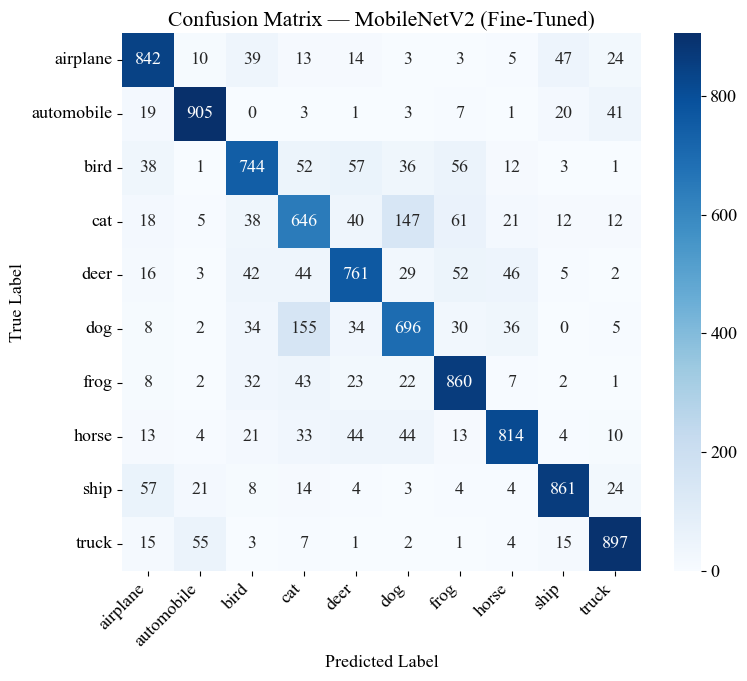

Saved: /content/drive/MyDrive/DL/Experiment4_Figures/07_misclassified_images.eps


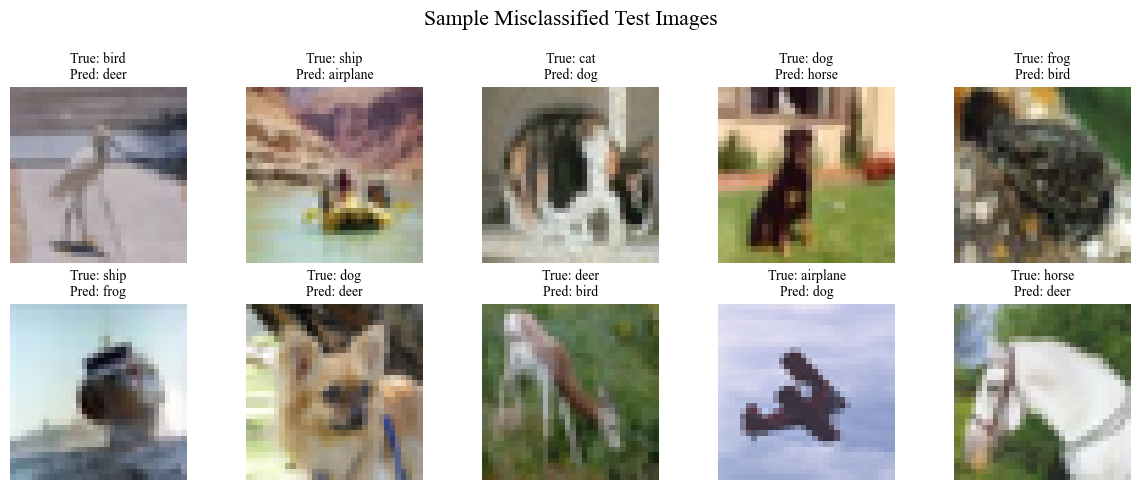

In [11]:
# ---- Confusion matrix ----
cm = confusion_matrix(y_test_int, y_pred_int)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names,
            yticklabels=label_names, ax=ax, cbar=True)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — MobileNetV2 (Fine-Tuned)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_fig(fig, "06_confusion_matrix")
plt.show()

# ---- Misclassified images (optional mandatory plot) ----
misclassified_idx = np.where(y_pred_int != y_test_int)[0]
sample_idx = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_test[idx])
    ax.set_title(f"True: {label_names[y_test_int[idx]]}\nPred: {label_names[y_pred_int[idx]]}",
                 fontsize=10)
    ax.axis('off')
fig.suptitle("Sample Misclassified Test Images")
plt.tight_layout()
save_fig(fig, "07_misclassified_images")
plt.show()

## Section 16: Hyperparameter Study (Randomized Search, Subsampled)

The full grid (2 x 3 x 2 x 2 x 2 x 2 = 96 combinations) is too large to search exhaustively in a
lab setting, so — following the same approach as the previous CIFAR/Fashion-MNIST lab — a handful
of combinations are sampled at random and evaluated on a **smaller stratified subset**
(400 images/class train, 100 images/class test) so the whole study finishes quickly. The values
themselves (learning rate, batch size, epochs, optimizer, dense units, frozen mode) are exactly
the ones listed in the manual.

In [12]:
def stratified_subsample(X, y_int, n_per_class, num_classes=NUM_CLASSES, seed=SEED):
    rng = np.random.default_rng(seed)
    chosen = []
    for c in range(num_classes):
        idx_c = np.where(y_int == c)[0]
        take = rng.choice(idx_c, size=min(n_per_class, len(idx_c)), replace=False)
        chosen.append(take)
    chosen = np.concatenate(chosen)
    rng.shuffle(chosen)
    return X[chosen], y_int[chosen]

SEARCH_TRAIN_PER_CLASS = 400
SEARCH_TEST_PER_CLASS = 100
N_ITER = 8

X_search_train, y_search_train_int = stratified_subsample(X_train, y_train_int, SEARCH_TRAIN_PER_CLASS)
X_search_test, y_search_test_int = stratified_subsample(X_test, y_test_int, SEARCH_TEST_PER_CLASS)
y_search_train_oh = tf.keras.utils.to_categorical(y_search_train_int, NUM_CLASSES)
y_search_test_oh = tf.keras.utils.to_categorical(y_search_test_int, NUM_CLASSES)
print("Hyperparameter-search subset sizes:", len(X_search_train), "train /", len(X_search_test), "test")

Hyperparameter-search subset sizes: 4000 train / 1000 test


In [13]:
HP_GRID = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [16, 32, 64],
    'epochs': [10, 20],
    'optimizer': ['adam', 'sgd'],
    'dense_units': [128, 256],
    'frozen': ['all', 'partial'],
}

def sample_combos(grid, n_iter, seed=SEED):
    rng = random.Random(seed)
    keys = list(grid.keys())
    all_combos = list(itertools.product(*[grid[k] for k in keys]))
    rng.shuffle(all_combos)
    sampled = all_combos[:n_iter]
    return [dict(zip(keys, c)) for c in sampled]

def get_optimizer(name, lr):
    if name == 'adam':
        return optimizers.Adam(learning_rate=lr)
    elif name == 'sgd':
        return optimizers.SGD(learning_rate=lr, momentum=0.9)
    raise ValueError(name)

combos = sample_combos(HP_GRID, N_ITER)
search_results = []

for i, cfg in enumerate(combos, start=1):
    tf.keras.backend.clear_session()
    model_i, base_i = build_transfer_model(
        tf.keras.applications.MobileNetV2, dense_units=cfg['dense_units'],
        frozen=cfg['frozen'], unfreeze_last_n=FT_UNFREEZE_LAST_N,
        model_name=f"search_{i}")
    model_i.compile(optimizer=get_optimizer(cfg['optimizer'], cfg['learning_rate']),
                     loss='categorical_crossentropy', metrics=['accuracy'])

    tr_ds_i = make_dataset(X_search_train, y_search_train_oh, batch_size=cfg['batch_size'], shuffle=True)
    te_ds_i = make_dataset(X_search_test, y_search_test_oh, batch_size=cfg['batch_size'], shuffle=False)

    t0 = time.time()
    h_i = model_i.fit(tr_ds_i, epochs=cfg['epochs'], shuffle=False, verbose=0)
    elapsed = time.time() - t0
    val_loss_i, val_acc_i = model_i.evaluate(te_ds_i, verbose=0)

    row = dict(cfg)
    row['combo_id'] = i
    row['val_accuracy'] = val_acc_i
    row['train_time_s'] = elapsed
    search_results.append(row)
    print(f"[{i}/{N_ITER}] {cfg} -> val_acc={val_acc_i:.4f}  ({elapsed:.1f}s)")

search_df = pd.DataFrame(search_results).sort_values('val_accuracy', ascending=False).reset_index(drop=True)

[1/8] {'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 10, 'optimizer': 'sgd', 'dense_units': 128, 'frozen': 'all'} -> val_acc=0.6170  (31.0s)
[2/8] {'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 20, 'optimizer': 'adam', 'dense_units': 256, 'frozen': 'partial'} -> val_acc=0.7430  (72.4s)
[3/8] {'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 20, 'optimizer': 'sgd', 'dense_units': 256, 'frozen': 'all'} -> val_acc=0.7350  (50.4s)
[4/8] {'learning_rate': 0.001, 'batch_size': 16, 'epochs': 20, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'partial'} -> val_acc=0.6940  (71.3s)
[5/8] {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 10, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'partial'} -> val_acc=0.5750  (37.1s)
[6/8] {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 20, 'optimizer': 'adam', 'dense_units': 256, 'frozen': 'all'} -> val_acc=0.7770  (40.0s)
[7/8] {'learning_rate': 0.001, 'batch_size': 16, 'epochs': 10, 'optimizer': 'adam', 'dense_units': 

=== Hyperparameter Search Results (ranked) ===
 learning_rate  batch_size  epochs optimizer  dense_units  frozen  combo_id  val_accuracy  train_time_s
        0.0010          32      20      adam          256     all         6         0.777     40.002752
        0.0001          16      20      adam          256 partial         2         0.743     72.447998
        0.0001          16      20       sgd          256     all         3         0.735     50.384906
        0.0010          16      20      adam          128 partial         4         0.694     71.260781
        0.0001          32      10       sgd          128     all         8         0.662     23.972263
        0.0001          64      10       sgd          128     all         1         0.617     31.013102
        0.0010          64      10      adam          128 partial         5         0.575     37.070862
        0.0010          16      10      adam          128 partial         7         0.528     45.704241

Best combination

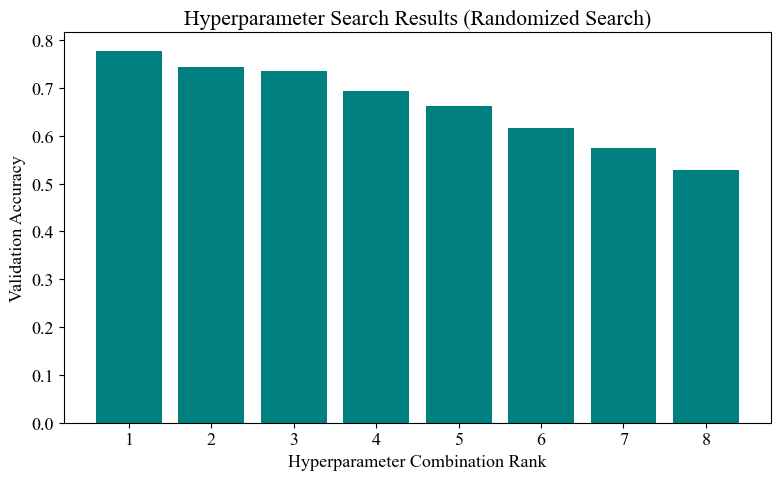

In [14]:
print("=== Hyperparameter Search Results (ranked) ===")
print(search_df.to_string(index=False))
best_combo = search_df.iloc[0]
print("\nBest combination:")
print(best_combo)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(search_df) + 1), search_df['val_accuracy'], color='teal')
ax.set_xlabel('Hyperparameter Combination Rank')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Hyperparameter Search Results (Randomized Search)')
plt.tight_layout()
save_fig(fig, "08_hyperparameter_search")
plt.show()

## Section 20: Additional Exercises

Run on a smaller stratified subset (600 images/class train, 150 images/class test) so each
architecture run stays quick.

### Exercise 1 — VGG16 Transfer Learning (subset)

In [15]:
SUBSET_TRAIN_PER_CLASS = 600
SUBSET_TEST_PER_CLASS = 150
SUBSET_EPOCHS = 8

X_sub_train, y_sub_train_int = stratified_subsample(X_train, y_train_int, SUBSET_TRAIN_PER_CLASS, seed=SEED + 1)
X_sub_test, y_sub_test_int = stratified_subsample(X_test, y_test_int, SUBSET_TEST_PER_CLASS, seed=SEED + 1)
y_sub_train_oh = tf.keras.utils.to_categorical(y_sub_train_int, NUM_CLASSES)
y_sub_test_oh = tf.keras.utils.to_categorical(y_sub_test_int, NUM_CLASSES)
print("Additional-exercise subset sizes:", len(X_sub_train), "train /", len(X_sub_test), "test")

sub_train_ds = make_dataset(X_sub_train, y_sub_train_oh, shuffle=True)
sub_test_ds = make_dataset(X_sub_test, y_sub_test_oh, shuffle=False)

def run_architecture(base_ctor, name):
    tf.keras.backend.clear_session()
    model, base = build_transfer_model(base_ctor, dense_units=128, frozen='all', model_name=name)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    model.fit(sub_train_ds, epochs=SUBSET_EPOCHS, shuffle=False, verbose=1)
    elapsed = time.time() - t0
    y_prob = model.predict(sub_test_ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_sub_test_int, y_pred)
    params = model.count_params()
    print(f"\n{name}: test accuracy = {acc:.4f} | params = {params:,} | training time = {elapsed:.2f}s")
    return {'model': name, 'accuracy': acc, 'params': params, 'train_time_s': elapsed}

vgg16_result = run_architecture(tf.keras.applications.VGG16, "VGG16_transfer")

Additional-exercise subset sizes: 6000 train / 1500 test
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.4207 - loss: 1.7455
Epoch 2/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.5668 - loss: 1.2872
Epoch 3/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.6085 - loss: 1.1495
Epoch 4/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.6302 - loss: 1.0780
Epoch 5/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.6558 - loss: 1.0184
Epoch 6/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.6713 - loss: 0.9681
Epoch 7/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.6815 - loss: 0.9266
Epoch 8/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6908 - loss: 0.9064

VGG16_transfer: test accuracy = 0.6307 | params = 14,781,642 | training time = 69.90s


### Exercise 2 — ResNet50 Transfer Learning (subset)

In [16]:
resnet50_result = run_architecture(tf.keras.applications.ResNet50, "ResNet50_transfer")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.1280 - loss: 2.2930
Epoch 2/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.1772 - loss: 2.2185
Epoch 3/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2112 - loss: 2.1376
Epoch 4/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.2363 - loss: 2.0740
Epoch 5/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.2558 - loss: 2.0298
Epoch 6/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.2672 - loss: 1.9943
Epoch 7/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.2685 - loss: 1.9738
Epoch 8/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.2900 - loss: 1.9407

ResNet50_transfer: test accuracy = 0.3053 | params = 23,851,274 | training time = 50.90s


### Exercise 3 — Adam vs SGD

Pulled directly from the Section 16 search results (`search_df` already varies `optimizer` across
its sampled combinations) rather than training anything new.

=== Additional Exercise 3: Adam vs SGD (from Section 16 search results) ===
           mean_val_accuracy  best_val_accuracy  combos_sampled
optimizer                                                      
adam                0.663400              0.777               5
sgd                 0.671333              0.735               3
Saved: /content/drive/MyDrive/DL/Experiment4_Figures/11_adam_vs_sgd.eps


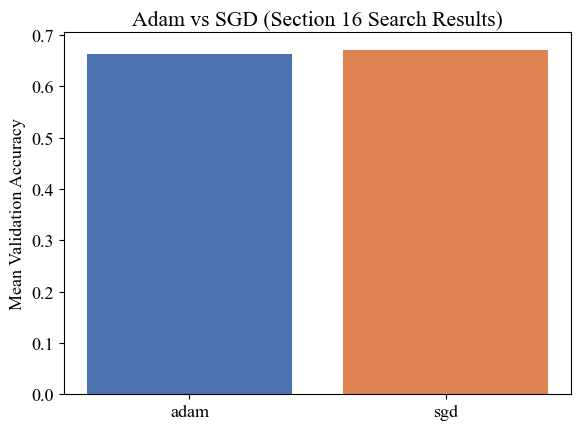

In [17]:
print("=== Additional Exercise 3: Adam vs SGD (from Section 16 search results) ===")
optimizer_compare = search_df.groupby('optimizer')['val_accuracy'].agg(['mean', 'max', 'count'])
optimizer_compare.columns = ['mean_val_accuracy', 'best_val_accuracy', 'combos_sampled']
print(optimizer_compare)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(optimizer_compare.index, optimizer_compare['mean_val_accuracy'], color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Mean Validation Accuracy')
ax.set_title('Adam vs SGD (Section 16 Search Results)')
plt.tight_layout()
save_fig(fig, "11_adam_vs_sgd")
plt.show()

### Exercise 4 — Frozen Layers vs Fine-Tuning

Pulled directly from the Task 3 / Task 4 results on the main MobileNetV2 model (`pre_ft_acc` and
`post_ft_acc`), rather than training anything new.

=== Additional Exercise 4: Frozen Backbone vs Fine-Tuned (MobileNetV2) ===
Frozen backbone only (Task 3) : test accuracy = 0.8054
Fine-tuned, last block (Task 4): test accuracy = 0.8026
Change from fine-tuning        : -0.0028
Saved: /content/drive/MyDrive/DL/Experiment4_Figures/12_frozen_vs_finetuned.eps


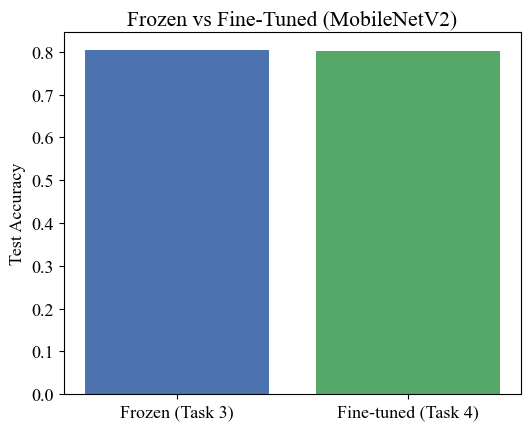

In [18]:
print("=== Additional Exercise 4: Frozen Backbone vs Fine-Tuned (MobileNetV2) ===")
print(f"Frozen backbone only (Task 3) : test accuracy = {pre_ft_acc:.4f}")
print(f"Fine-tuned, last block (Task 4): test accuracy = {post_ft_acc:.4f}")
print(f"Change from fine-tuning        : {post_ft_acc - pre_ft_acc:+.4f}")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.bar(['Frozen (Task 3)', 'Fine-tuned (Task 4)'], [pre_ft_acc, post_ft_acc],
       color=['#4C72B0', '#55A868'])
ax.set_ylabel('Test Accuracy')
ax.set_title('Frozen vs Fine-Tuned (MobileNetV2)')
plt.tight_layout()
save_fig(fig, "12_frozen_vs_finetuned")
plt.show()

### Exercise 5 — Precision, Recall and F1-score

Pulled directly from the Task 5 evaluation of the final fine-tuned MobileNetV2 model
(`final_prec`, `final_rec`, `final_f1`), rather than recomputing anything.

In [19]:
print("=== Additional Exercise 5: Precision, Recall, F1-score (MobileNetV2, fine-tuned, from Task 5) ===")
print(f"Precision : {final_prec:.4f}")
print(f"Recall    : {final_rec:.4f}")
print(f"F1-score  : {final_f1:.4f}")

=== Additional Exercise 5: Precision, Recall, F1-score (MobileNetV2, fine-tuned, from Task 5) ===
Precision : 0.8028
Recall    : 0.8026
F1-score  : 0.8024


### Exercise 6 — LeNet-5 vs AlexNet-Style vs ResNet50

No pretrained "AlexNet" or "LeNet-5" weights exist in `keras.applications` (they predate that
API), and neither's original design fits CIFAR-10's 32x32 resolution directly (AlexNet expects
227x227; LeNet-5 expects 32x32 but single-channel MNIST digits). Both are implemented here as the
standard from-scratch adaptations for CIFAR-10 — LeNet-5's classic 2-conv/2-avgpool/3-FC structure,
and AlexNet's 5-conv-block/FC structure with smaller kernels sized for 32x32 — trained from scratch
(no transfer learning, since neither has pretrained weights) and compared against the ResNet50
transfer-learning run from Exercise 2.

In [20]:
def build_lenet5_style(input_shape=(32, 32, 3), num_classes=NUM_CLASSES):
    m = models.Sequential(name="LeNet5_style_CIFAR")
    m.add(layers.Input(shape=input_shape))
    m.add(layers.Conv2D(6, 5, padding='same', activation='relu'))
    m.add(layers.AveragePooling2D(2))
    m.add(layers.Conv2D(16, 5, padding='valid', activation='relu'))
    m.add(layers.AveragePooling2D(2))
    m.add(layers.Flatten())
    m.add(layers.Dense(120, activation='relu'))
    m.add(layers.Dense(84, activation='relu'))
    m.add(layers.Dense(num_classes, activation='softmax'))
    return m

def build_alexnet_style(input_shape=(32, 32, 3), num_classes=NUM_CLASSES):
    m = models.Sequential(name="AlexNet_style_CIFAR")
    m.add(layers.Input(shape=input_shape))
    m.add(layers.Conv2D(64, 3, padding='same', activation='relu'))
    m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2))
    m.add(layers.Conv2D(192, 3, padding='same', activation='relu'))
    m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2))
    m.add(layers.Conv2D(384, 3, padding='same', activation='relu'))
    m.add(layers.Conv2D(256, 3, padding='same', activation='relu'))
    m.add(layers.Conv2D(256, 3, padding='same', activation='relu'))
    m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2))
    m.add(layers.Flatten())
    m.add(layers.Dense(1024, activation='relu'))
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(512, activation='relu'))
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(num_classes, activation='softmax'))
    return m

tf.keras.backend.clear_session()
alexnet_model = build_alexnet_style()
alexnet_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                       loss='categorical_crossentropy', metrics=['accuracy'])

sub_train_ds_32 = make_dataset(X_sub_train, y_sub_train_oh, img_size=32, shuffle=True)
sub_test_ds_32 = make_dataset(X_sub_test, y_sub_test_oh, img_size=32, shuffle=False)

t0 = time.time()
alexnet_model.fit(sub_train_ds_32, epochs=SUBSET_EPOCHS, shuffle=False, verbose=1)
alexnet_time = time.time() - t0
y_prob_ax = alexnet_model.predict(sub_test_ds_32, verbose=0)
y_pred_ax = np.argmax(y_prob_ax, axis=1)
alexnet_acc = accuracy_score(y_sub_test_int, y_pred_ax)
alexnet_params = alexnet_model.count_params()

alexnet_result = {'model': 'AlexNet_style_scratch', 'accuracy': alexnet_acc,
                   'params': alexnet_params, 'train_time_s': alexnet_time}

tf.keras.backend.clear_session()
lenet5_model = build_lenet5_style()
lenet5_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
lenet5_model.fit(sub_train_ds_32, epochs=SUBSET_EPOCHS, shuffle=False, verbose=1)
lenet5_time = time.time() - t0
y_prob_ln = lenet5_model.predict(sub_test_ds_32, verbose=0)
y_pred_ln = np.argmax(y_prob_ln, axis=1)
lenet5_acc = accuracy_score(y_sub_test_int, y_pred_ln)
lenet5_params = lenet5_model.count_params()

lenet5_result = {'model': 'LeNet5_style_scratch', 'accuracy': lenet5_acc,
                  'params': lenet5_params, 'train_time_s': lenet5_time}

print("\n=== Exercise 6: LeNet-5 vs AlexNet-Style vs ResNet50 ===")
print(f"LeNet-5-style (from scratch)  : test accuracy = {lenet5_acc:.4f} | "
      f"params = {lenet5_params:,} | training time = {lenet5_time:.2f}s")
print(f"AlexNet-style (from scratch)  : test accuracy = {alexnet_acc:.4f} | "
      f"params = {alexnet_params:,} | training time = {alexnet_time:.2f}s")
print(f"ResNet50 (transfer learning)  : test accuracy = {resnet50_result['accuracy']:.4f} | "
      f"params = {resnet50_result['params']:,} | training time = {resnet50_result['train_time_s']:.2f}s")

Epoch 1/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.1992 - loss: 2.6555
Epoch 2/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2943 - loss: 1.9513
Epoch 3/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3235 - loss: 1.8264
Epoch 4/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3665 - loss: 1.7334
Epoch 5/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4032 - loss: 1.6331
Epoch 6/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4295 - loss: 1.5636
Epoch 7/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4535 - loss: 1.4844
Epoch 8/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4948 - loss: 1.4089
Epoch 1/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.2552 - loss: 2.0357
Epoch 2/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3605 - loss: 1.7635
Epoch 3/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4038 - loss: 1.6419
Epoch 4/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - ac

## Summary: Architecture Comparison (Section 18.2) and Final Results

=== Architecture Comparison ===
                           model  accuracy   params  train_time_s
MobileNetV2 (main, full dataset)  0.802600  2423242    409.016357
                  VGG16_transfer  0.630667 14781642     69.900330
               ResNet50_transfer  0.305333 23851274     50.900200
           AlexNet_style_scratch  0.443333  6978890     33.014102
            LeNet5_style_scratch  0.476000    83126     11.103601
Saved: /content/drive/MyDrive/DL/Experiment4_Figures/09_architecture_comparison_accuracy.eps


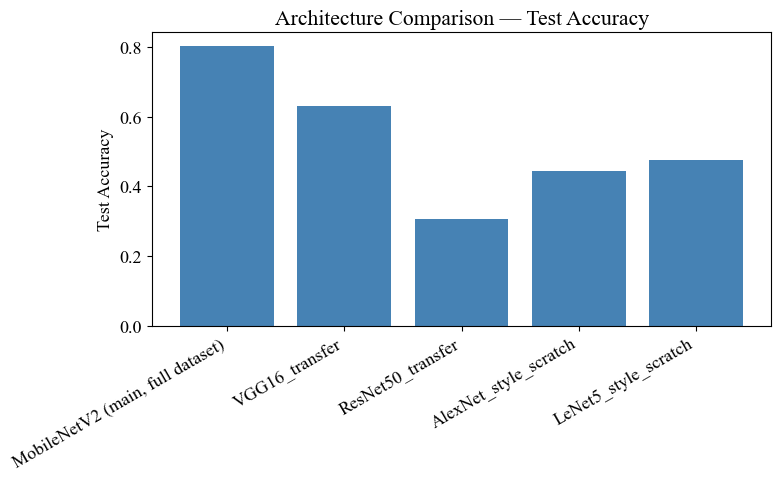

Saved: /content/drive/MyDrive/DL/Experiment4_Figures/10_architecture_comparison_time.eps


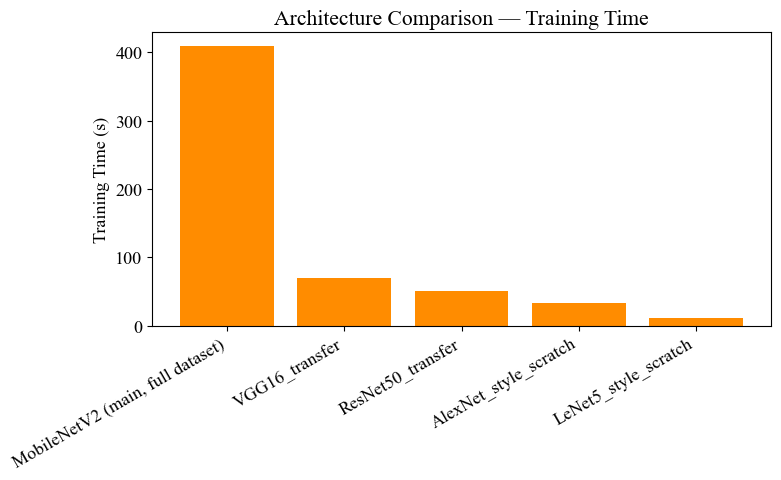

In [21]:
comparison_rows = [
    {'model': 'MobileNetV2 (main, full dataset)', 'accuracy': final_acc,
     'params': total_params_mobilenet, 'train_time_s': total_time_mobilenet},
    vgg16_result, resnet50_result, alexnet_result, lenet5_result,
]
comparison_df = pd.DataFrame(comparison_rows)
print("=== Architecture Comparison ===")
print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(comparison_df['model'], comparison_df['accuracy'], color='steelblue')
ax.set_ylabel('Test Accuracy')
ax.set_title('Architecture Comparison — Test Accuracy')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_fig(fig, "09_architecture_comparison_accuracy")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(comparison_df['model'], comparison_df['train_time_s'], color='darkorange')
ax.set_ylabel('Training Time (s)')
ax.set_title('Architecture Comparison — Training Time')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_fig(fig, "10_architecture_comparison_time")
plt.show()

In [22]:
# ---- Consolidated printout: copy this back for the LaTeX report (Section 18) ----
print("############################################")
print("# SECTION 18.1 — MAIN MODEL (MobileNetV2)   #")
print("############################################")
print(f"Training Accuracy : {final_train_acc:.4f}")
print(f"Testing Accuracy  : {final_acc:.4f}")
print(f"Precision         : {final_prec:.4f}")
print(f"Recall            : {final_rec:.4f}")
print(f"F1-score          : {final_f1:.4f}")
print(f"Training Time (s) : {total_time_mobilenet:.2f}")
print(f"Total Parameters  : {total_params_mobilenet:,}")
print(f"Test acc. before fine-tuning : {pre_ft_acc:.4f}")
print(f"Test acc. after  fine-tuning : {post_ft_acc:.4f}")

print("\n############################################")
print("# SECTION 18.2 — ARCHITECTURE COMPARISON    #")
print("############################################")
print(comparison_df.to_string(index=False))

print("\n############################################")
print("# SECTION 16 — BEST HYPERPARAMETER COMBO    #")
print("############################################")
print(best_combo)

############################################
# SECTION 18.1 — MAIN MODEL (MobileNetV2)   #
############################################
Training Accuracy : 0.8669
Testing Accuracy  : 0.8026
Precision         : 0.8028
Recall            : 0.8026
F1-score          : 0.8024
Training Time (s) : 409.02
Total Parameters  : 2,423,242
Test acc. before fine-tuning : 0.8054
Test acc. after  fine-tuning : 0.8026

############################################
# SECTION 18.2 — ARCHITECTURE COMPARISON    #
############################################
                           model  accuracy   params  train_time_s
MobileNetV2 (main, full dataset)  0.802600  2423242    409.016357
                  VGG16_transfer  0.630667 14781642     69.900330
               ResNet50_transfer  0.305333 23851274     50.900200
           AlexNet_style_scratch  0.443333  6978890     33.014102
            LeNet5_style_scratch  0.476000    83126     11.103601

############################################
# SECTION 16 — BE

## Save / Download All Figures

Figures are already saved to `My Drive/DL/Experiment4_Figures/` as you go (so nothing is lost if
the runtime disconnects). This last cell also zips them up for a one-click local download.

In [23]:
zip_path = "/content/Experiment4_Figures.zip"
with zipfile.ZipFile(zip_path, 'w') as zf:
    for f in sorted(glob.glob(os.path.join(FIG_DIR, "*.eps"))):
        zf.write(f, arcname=os.path.basename(f))
print("Zipped", len(glob.glob(os.path.join(FIG_DIR, '*.eps'))), "figures ->", zip_path)

from google.colab import files
files.download(zip_path)

Zipped 12 figures -> /content/Experiment4_Figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>